In [23]:
# Setup: Import all required libraries.
# - OpenCV: image processing
# - NumPy: numerical operations
# - Matplotlib: visualization
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (4,4)

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

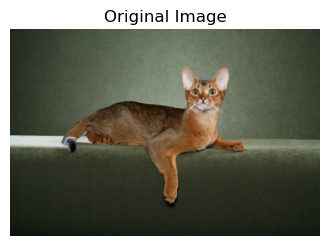

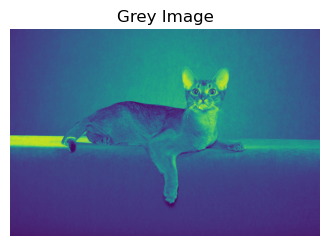

In [25]:
# ==========================================
# 1. Load One Example Image
# ==========================================
# We start with a single image to understand how segmentation works.
image_path = "./dataset/images/Abyssinian_1.jpg" # This is the image
annotation_path = "./dataset/masks/Abyssinian_1.png" # The corresponding annotation (mask), we will use it as ground truth
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
plt.figure(1)
plt.title("Original Image")
plt.imshow(image)
plt.axis('off')
plt.figure(2)
plt.title("Grey Image")
plt.imshow(gray)
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

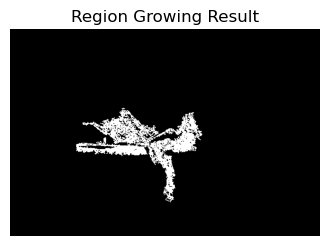

In [26]:
# ==========================================
# 2. Region Growing (Demo on Single Image)
# ==========================================
# Region growing starts from a seed pixel and expands to neighbors if they are similar in intensity.
# Key parameters:
# - seed: starting pixel
# - threshold: how similar pixels must be
# Simple implementation inline (for understanding)
from inspect import stack

from sklearn import neighbors


def region_growing_demo(image, seed, threshold=15):
    h, w = image.shape # get the height and width of the image
    segmented = np.zeros((h, w), dtype=np.uint8) # output segmented image, here we hold the reusltant image
    visited = np.zeros((h, w), dtype=bool) # this keeps tracks of which pixels have been visited to avoid infinite loops
    seed_value = image[seed] # we input a random pixel, and get its intensity value
    stack = [seed] # stack that will hold pixels to explore
    while stack:
        x, y = stack.pop() # get the last pixel from the stack
        if visited[x, y]:
            continue # if we have already visited this pixel, skip it
        visited[x, y] = True # mark this pixel as visited
        if abs(int(image[x, y]) - int(seed_value)) < threshold:
            segmented[x, y] = 255 #if the difference in intensity is less than the threshold, we consider it part of the region and set it to 255 (white) in the segmented image
            # 4-connected neighbors
            neighbors = [(x-1,y),(x+1,y),(x,y-1),(x,y+1)] #if the neighboring pixels are within the image bounds, we add them to the stack to be explored next
            for nx, ny in neighbors:
                if 0 <= nx < h and 0 <= ny < w:
                    stack.append((nx, ny))

    return segmented
# Try different seeds and thresholds to observe behavior
h, w = gray.shape # get the height and width of the image
seed = (h//2, w//2) # let's start with the central pixel
region_result = region_growing_demo(gray, seed, threshold=15) #apply region growing with the specified seed and threshold
plt.title("Region Growing Result")
plt.imshow(region_result, cmap='gray')
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

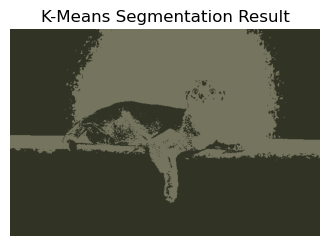

In [ ]:
# ==========================================
# 2. K-Means Segmentation (Demo on Single Image)
# ==========================================
# K-Means clusters pixels into K groups based on similarity.
# We must specify the number of clusters (K).
# Here, we use color features only: [R, G, B]
# Prepare data
Z = image.reshape((-1,3))
Z = np.float32(Z)
# Define number of clusters
K = 2
# Apply K-Means
criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0) # termination criteria: either 10 iterations or accuracy of 1.0
_, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS) # apply k-means clustering to the pixel data
# Convert back to image
centers = np.uint8(centers) #center values are the mean color of each cluster, we convert them back to uint8 format
segmented_kmeans = centers[labels.flatten()] # we look up the cluster center for each pixel and create the segmented image by replacing each pixel's color with the color of its cluster center
segmented_kmeans = segmented_kmeans.reshape((image.shape))
plt.title("K-Means Segmentation Result")
plt.imshow(segmented_kmeans)
plt.axis('off')

(np.float64(-0.5), np.float64(599.5), np.float64(399.5), np.float64(-0.5))

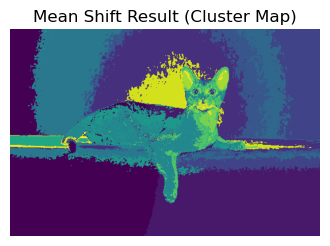

In [ ]:
# ==========================================
# 3. Mean Shift (Demo on Single Image)
# ==========================================
# In image segmentation, the feature space typically includes:
# - Color (R, G, B)
# - Spatial position (x, y)
# Key parameters:
# - bandwidth: controls the size of the neighborhood (very important!)
# * small bandwidth → many small segments (over-segmentation)
# * large bandwidth → fewer large regions (under-segmentation)
from sklearn.cluster import MeanShift
h, w, _ = image.shape
# Build feature vectors: [R, G, B, x, y]
X = []
for i in range(h):
    for j in range(w):
        r, g, b = image[i, j]
        X.append([r, g, b, i/10, j/10]) # gives image color and spatial information, we divide x and y by 10 to scale down the spatial features so that they are on a similar scale as the color features
X = np.array(X)
# Apply Mean Shift clustering
ms = MeanShift(bandwidth=20, bin_seeding=True)
labels = ms.fit_predict(X)
segmented = labels.reshape((h, w))
plt.title("Mean Shift Result (Cluster Map)")
plt.imshow(segmented)
plt.axis('off')